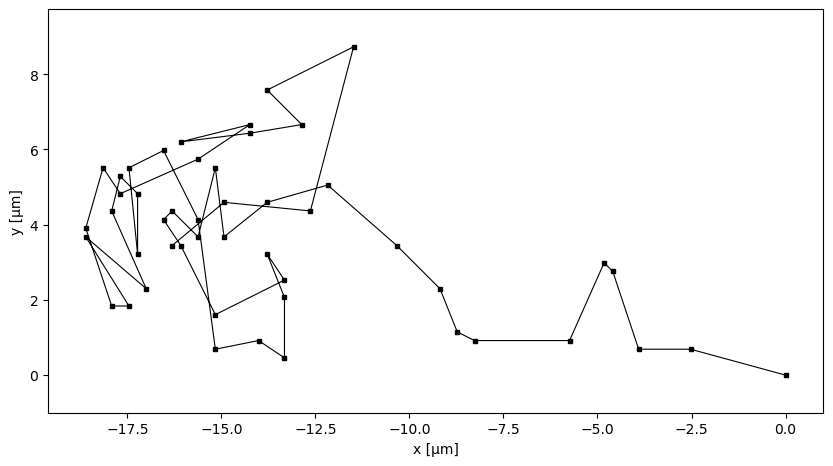

In [2]:
import matplotlib.pyplot as plt

# 1. Kalibrační faktor (převod z pixelů na mikrometry)
# Získáno z 3. řádku vašeho souboru: 2.29707566421E-0001
kalibrace = 0.229707566421

# 2. Naměřená data v pixelech (vloženo přímo ze souboru, celkem 49 poloh)
x_pixely = [
    957, 946, 940, 937, 936, 932, 921, 919, 917, 912, 904, 897, 892, 
    891, 889, 886, 885, 887, 891, 899, 897, 899, 899, 896, 891, 889, 
    885, 881, 882, 882, 880, 879, 883, 876, 881, 879, 876, 878, 880, 
    889, 895, 887, 895, 901, 897, 907, 902, 892, 886
]

y_pixely = [
    563, 560, 560, 551, 550, 559, 559, 558, 553, 548, 541, 543, 547, 
    539, 547, 544, 545, 548, 556, 552, 549, 554, 561, 559, 560, 545, 
    537, 539, 549, 542, 540, 544, 553, 547, 555, 555, 546, 539, 542, 
    538, 534, 536, 535, 534, 530, 525, 544, 543, 548
]

# Výchozí bod (počátek 0, 0)
x0 = x_pixely[0]
y0 = y_pixely[0]

# 3. Přepočet do mikrometrů pro osy X a Y
x_um = []
y_um = []

for x, y in zip(x_pixely, y_pixely):
    # Osa X: rozdíl polohy vůči počátku * kalibrace
    x_um.append((x - x0) * kalibrace)
    
    # Osa Y: u osy Y na monitorech/kamerách roste hodnota směrem dolů,
    # proto v grafu počítáme (y0 - y), aby šla trajektorie správně nahoru.
    y_um.append((y0 - y) * kalibrace)

# 4. Vykreslení grafu
plt.figure(figsize=(10, 7))

# Černá linka, černé body, přesně jako na vytištěném papíře
plt.plot(x_um, y_um, color='black', marker='s', markersize=3, linestyle='-', linewidth=0.8)

# Popisky os s jednotkami
plt.xlabel('x [µm]')
plt.ylabel('y [µm]')

# Nastavení os - odstranění vnitřní mřížky a zachování stejného měřítka na X a Y
plt.grid(False)
ax = plt.gca()
ax.set_aspect('equal', adjustable='box') 

# Tímto upravíme rozsah os, aby graf vizuálně přesně odpovídal papíru
plt.xlim(min(x_um) - 1, max(x_um) + 1)
plt.ylim(min(y_um) - 1, max(y_um) + 1)

# Zobrazení samotného grafu
plt.show()

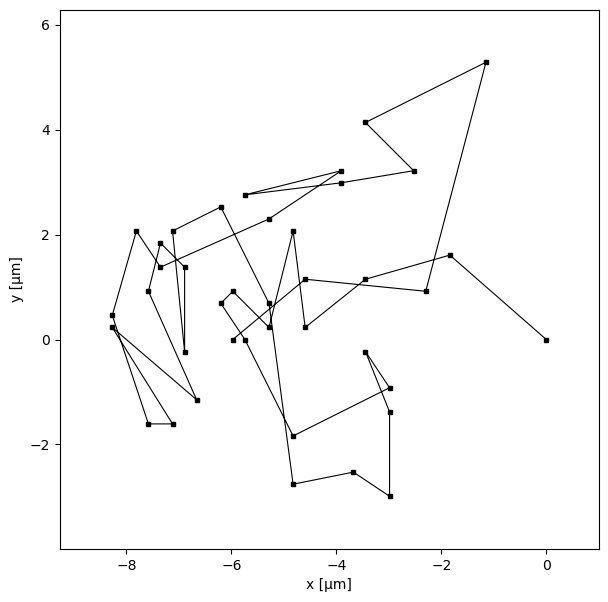

In [8]:
import matplotlib.pyplot as plt

# 1. Kalibrační faktor
kalibrace = 0.229707566421

# 2. Původní kompletní data v pixelech
x_pixely_vse = [
    957, 946, 940, 937, 936, 932, 921, 919, 917, 912, 904, 897, 892, 
    891, 889, 886, 885, 887, 891, 899, 897, 899, 899, 896, 891, 889, 
    885, 881, 882, 882, 880, 879, 883, 876, 881, 879, 876, 878, 880, 
    889, 895, 887, 895, 901, 897, 907, 902, 892, 886
]

y_pixely_vse = [
    563, 560, 560, 551, 550, 559, 559, 558, 553, 548, 541, 543, 547, 
    539, 547, 544, 545, 548, 556, 552, 549, 554, 561, 559, 560, 545, 
    537, 539, 549, 542, 540, 544, 553, 547, 555, 555, 546, 539, 542, 
    538, 534, 536, 535, 534, 530, 525, 544, 543, 548
]

# EXPERIMENT: Oříznutí - odebereme prvních 9 poloh
x_pixely = x_pixely_vse[9:]
y_pixely = y_pixely_vse[9:]

# Výchozí bod (počátek 0, 0 bude nyní tam, kde byla částice v 10. kroku)
x0 = x_pixely[0]
y0 = y_pixely[0]

# 3. Přepočet do mikrometrů
x_um = []
y_um = []

for x, y in zip(x_pixely, y_pixely):
    x_um.append((x - x0) * kalibrace)
    # Zde opět otáčíme osu Y, aby graf směřoval nahoru
    y_um.append((y0 - y) * kalibrace)

# 4. Vykreslení grafu
plt.figure(figsize=(10, 7))

plt.plot(x_um, y_um, color='black', marker='s', markersize=3, linestyle='-', linewidth=0.8)

plt.xlabel('x [µm]')
plt.ylabel('y [µm]')

plt.grid(False)
ax = plt.gca()
ax.set_aspect('equal', adjustable='box') 

# Rozsah os přizpůsobíme novým hodnotám
plt.xlim(min(x_um) - 1, max(x_um) + 1)
plt.ylim(min(y_um) - 1, max(y_um) + 1)

plt.show()

In [7]:
import numpy as np
from scipy.optimize import curve_fit
from uncertainties import ufloat
from uncertainties.umath import *
import math

# ==========================================
# 1. ZPRACOVÁNÍ DAT O ČÁSTICÍCH (TVRDĚ ZADÁNO V KÓDU)
# ==========================================
# Změřené průměry částic z programu Solarius (v nanometrech) - celkem 18 částic
diameters = np.array([
    417.31651376, 417.31651376, 433.83027523, 433.83027523, 
    433.83027523, 417.31651376, 417.31651376, 417.31651376, 
    417.31651376, 417.31651376, 417.31651376, 433.83027523, 
    417.31651376, 417.31651376, 417.31651376, 417.31651376, 
    417.31651376, 417.31651376
])

# Výpočet průměru, směrodatné odchylky a nejistoty průměru (SEM)
N_particles = len(diameters)
mean_diameter_nm = np.mean(diameters)
std_diameter_nm = np.std(diameters, ddof=1)
sem_diameter_nm = std_diameter_nm / np.sqrt(N_particles)

# Vytvoření objektu s chybou pro poloměr a převod z nm na metry (základní jednotka SI)
# Poloměr = průměr / 2
radius_nm = ufloat(mean_diameter_nm / 2, sem_diameter_nm / 2)
r = radius_nm * 1e-9 
print(f"Poloměr částice (r): {r:.2e} m")

# ==========================================
# 2. VÝPOČET AKTIVITY BROWNOVA POHYBU (A)
# ==========================================
# Data z protokolu - čas t (s) a střední kvadratické posunutí s^2
t_data = np.array([5, 10, 15, 20])

# Posunutí převedeme z mikrometrů čtverečních na metry čtvereční (* 1e-12)
s2_data = np.array([3.5, 7.3, 10.7, 13.8]) * 1e-12
s2_errors = np.array([0.5, 1.0, 1.5, 1.7]) * 1e-12

# Definiční funkce pro lineární regresi procházející počátkem: y = k * x
def linear_model(x, k):
    return k * x

# Proložení dat přímkou pomocí curve_fit (zahrneme i chyby y-hodnot - parametr sigma)
popt, pcov = curve_fit(linear_model, t_data, s2_data, sigma=s2_errors, absolute_sigma=True)

# Získání směrnice (k) a její směrodatné odchylky
k_val = popt[0]
k_err = np.sqrt(pcov[0][0])
k = ufloat(k_val, k_err)

# Výpočet aktivity A (z rovnice s^2 = 2At, proto A = k / 2)
A = k / 2
print(f"Směrnice přímky (2A): {k:.2e} m^2/s")
print(f"Aktivita Brownova pohybu (A): {A:.2e} m^2/s")

# ==========================================
# 3. VÝPOČET AVOGADROVY KONSTANTY (N_A)
# ==========================================
# Definování fyzikálních konstant a zadaných hodnot s chybami
R = 8.314 # Plynová konstanta [J / (mol K)], bez chyby

# Teplota: 23.1 °C +- 2.0 °C. Převod na Kelviny (+ 273.15)
T = ufloat(23.1 + 273.15, 2.0)

# Viskozita: 0.9 +- 0.1 mPa*s. Převod na Pa*s (* 1e-3)
eta = ufloat(0.9, 0.1) * 1e-3

# Vzorec pro N_A = (R * T) / (3 * pi * eta * r * A)
N_A = (R * T) / (3 * math.pi * eta * r * A)

# ==========================================
# 4. VÝPIS VÝSLEDKŮ
# ==========================================
print("\n--- ZÁVĚREČNÉ VÝSLEDKY ---")
print(f"Teplota (T): {T:.2f} K")
print(f"Viskozita (eta): {eta:.2e} Pa*s")
print(f"Avogadrova konstanta (N_A): {N_A:.2e} mol^-1")

Poloměr částice (r): (2.10+/-0.01)e-07 m
Směrnice přímky (2A): (7.07+/-0.48)e-13 m^2/s
Aktivita Brownova pohybu (A): (3.53+/-0.24)e-13 m^2/s

--- ZÁVĚREČNÉ VÝSLEDKY ---
Teplota (T): 296.25+/-2.00 K
Viskozita (eta): (9.00+/-1.00)e-04 Pa*s
Avogadrova konstanta (N_A): (3.90+/-0.51)e+24 mol^-1


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from uncertainties import ufloat
from uncertainties.umath import *
import math

# ==========================================
# 1. ZPRACOVÁNÍ DAT O ČÁSTICÍCH
# ==========================================
# Změřené průměry částic z programu Solarius (v nanometrech)
diameters = np.array([
    417.31651376, 417.31651376, 433.83027523, 433.83027523, 
    433.83027523, 417.31651376, 417.31651376, 417.31651376, 
    417.31651376, 417.31651376, 417.31651376, 433.83027523, 
    417.31651376, 417.31651376, 417.31651376, 417.31651376, 
    417.31651376, 417.31651376
])

N_particles = len(diameters)
mean_diameter_nm = np.mean(diameters)
std_diameter_nm = np.std(diameters, ddof=1)
sem_diameter_nm = std_diameter_nm / np.sqrt(N_particles)

# Poloměr = průměr / 2, převod z nm na m
radius_nm = ufloat(mean_diameter_nm / 2, sem_diameter_nm / 2)
r = radius_nm * 1e-9 

# ==========================================
# 2. NOVÁ DATA: POSUNUTÍ A OPRAVA KALIBRACE
# ==========================================
# Čas v sekundách
t_data = np.array([5, 10, 15, 20])

# Nové surové hodnoty z programu v mikrometrech čtverečních
s2_raw_um2 = np.array([3.55, 6.78, 9.13, 10.81])

# APLIKACE KOREKCE: Měření 40x objektiv, program kalibrován na 100x -> (100/40)^2 = 2.5^2 = 6.25
korekce = 6.25
s2_corrected_um2 = s2_raw_um2 * korekce

# Odhad chyb pro nová data (vezmeme podobnou relativní chybu jako v minulém protokolu)
s2_errors_um2 = np.array([0.5, 1.0, 1.5, 1.7]) * korekce

# Převod opravených dat na základní jednotky (metry čtvereční)
s2_data = s2_corrected_um2 * 1e-12
s2_errors = s2_errors_um2 * 1e-12

# ==========================================
# 4. VÝPOČET AVOGADROVY KONSTANTY (N_A)
# ==========================================
R = 8.314 # J/(mol K)
T = ufloat(23.1 + 273.15, 2.0) # Teplota K
eta = ufloat(0.9, 0.1) * 1e-3  # Viskozita Pa*s

# N_A = (R * T) / (3 * pi * eta * r * A)
N_A = (R * T) / (3 * math.pi * eta * r * A)

print("--- ZÁVĚREČNÉ VÝSLEDKY ---")
print(f"Opravená směrnice (2A): {k:.2e} m^2/s")
print(f"Opravená aktivita (A): {A:.2e} m^2/s")
print(f"Avogadrova konstanta (N_A): {N_A:.2e} mol^-1")

--- ZÁVĚREČNÉ VÝSLEDKY ---
Opravená směrnice (2A): (3.91+/-0.30)e-12 m^2/s
Opravená aktivita (A): (1.96+/-0.15)e-12 m^2/s
Avogadrova konstanta (N_A): (7.05+/-0.95)e+23 mol^-1
